In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.models import Sequential, Model
from keras.layers import Dense, Input

In [2]:
(X_train, _), (X_test, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


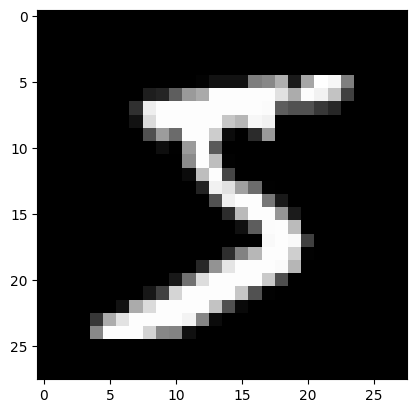

In [6]:
plt.imshow(X_train[0], cmap='gray')
plt.show()

In [8]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [10]:
X_train = X_train.reshape(len(X_train), np.prod(X_train.shape[1:]))
X_test = X_test.reshape(len(X_test), np.prod(X_test.shape[1:]))

In [11]:
x_train_noisy = X_train + 0.5 * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
x_test_noisy = X_test + 0.5 * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)

In [13]:
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

In [15]:
inputs = Input(shape=(784,))
encoder = Dense(32, activation='relu')(inputs)
decoder = Dense(784, activation='sigmoid')(encoder)
autoencoder = Model(inputs=inputs, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train_noisy, X_train, epochs=100, batch_size=256, shuffle=True, validation_data=(x_test_noisy, X_test))

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0534 - val_loss: 1.3199
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0041 - val_loss: 1.3118
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0040 - val_loss: 1.3105
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0040 - val_loss: 1.3093
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0040 - val_loss: 1.3102
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0040 - val_loss: 1.3084
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0040 - val_loss: 1.3094
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0040 - val_loss: 1.3074
Epoch 9/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0040 - val_loss: 1.3099
Epoch 10/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0040 - val_loss: 1.3097
Epoch 11/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0040 - val_loss: 1.3074
Epoch 12/100
235/235 ━━━━━━━━━━━━━━━━

In [51]:
idx = np.random.randint(X_test.shape[1])
original_image = X_test[idx]
noisy_image = original_image + 0.5 * np.random.normal(loc=0.0, scale=1.0, size=original_image.shape)
noisy_image = np.clip(noisy_image, 0.0, 1.0)

denoised_image = autoencoder.predict(np.expand_dims(noisy_image, axis=0))
denoised_image = denoised_image.reshape(28, 28)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

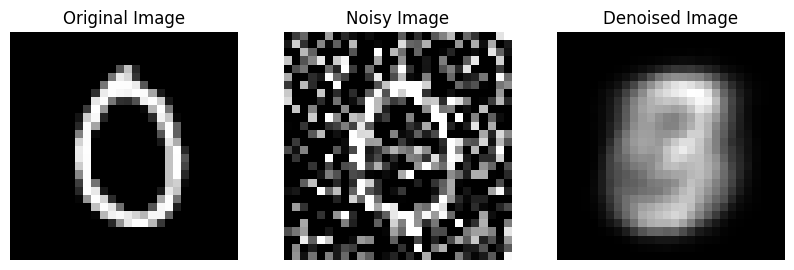

In [52]:
plt.figure(figsize=(10, 4))

plt.subplot(1,3,1)
plt.imshow(original_image.reshape(28, 28), cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(noisy_image.reshape(28, 28), cmap='gray')
plt.title('Noisy Image')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(denoised_image, cmap='gray')
plt.title('Denoised Image')
plt.axis('off')